In [79]:
#Common Model Algorithms
from sklearn import svm, tree, linear_model, neighbors, naive_bayes, ensemble, discriminant_analysis, gaussian_process
from xgboost import XGBClassifier

#Common Model Helpers
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn import feature_selection
from sklearn import model_selection
from sklearn import metrics

#Visualization
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import seaborn as sns
# from pandas.tools.plotting import scatter_matrix


In [80]:


import numpy as np
import tensorflow as tf
import pandas as pd
import random
import keras

import math
from keras.models import Sequential
from keras.layers import Dense, Activation, Dropout
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score
from scipy.stats import chi2_contingency, ttest_ind
from scipy import stats
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.ensemble import (RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, ExtraTreesClassifier)
import xgboost as xgb
import pprint
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
import lightgbm as lgb
from sklearn.tree import DecisionTreeClassifier


In [81]:

#Configure Visualization Defaults
#%matplotlib inline = show plots in Jupyter Notebook browser
%matplotlib inline
mpl.style.use('ggplot')
sns.set_style('white')
pylab.rcParams['figure.figsize'] = 12,8
pd.set_option('max_columns', None)

train_csv = "level_01_data/train.csv"
test_csv = "level_01_data/test.csv"
SS_csv = "level_01_data/submission_lvl_1.csv"

X = pd.read_csv(train_csv)
test_data = pd.read_csv(test_csv)
ss = pd.read_csv(SS_csv)



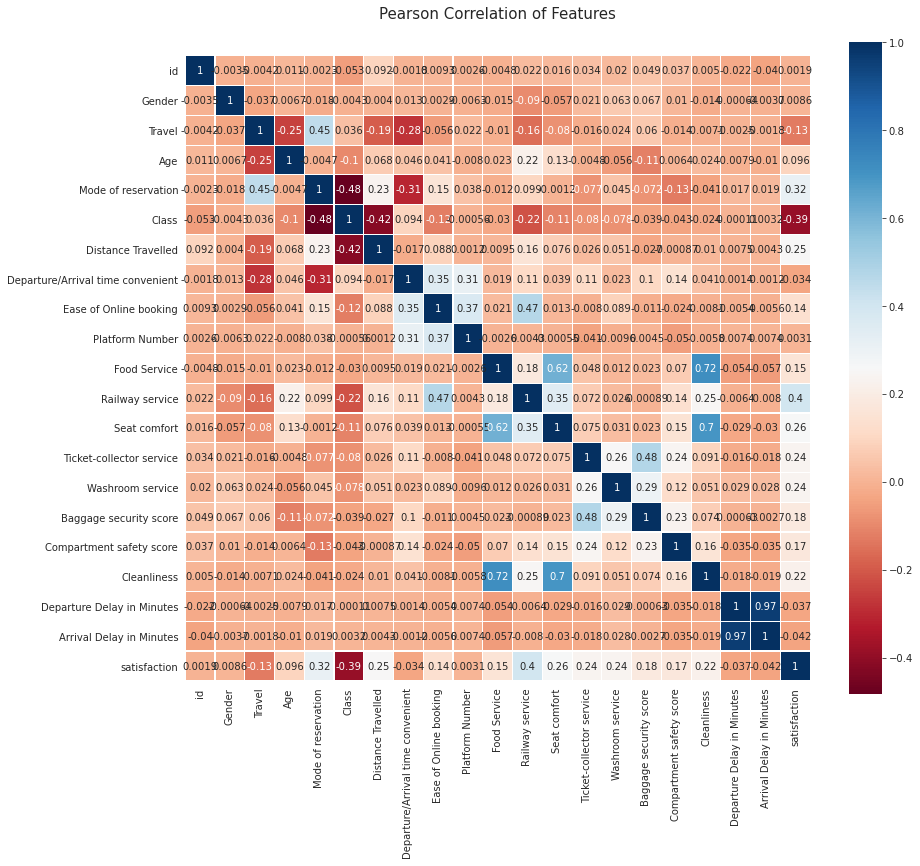

In [82]:
X = string_to_num(X)

colormap = plt.cm.RdBu
plt.figure(figsize=(14,12))
plt.title('Pearson Correlation of Features', y=1.05, size=15)
sns.heatmap(X.astype(float).corr(),linewidths=0.1,vmax=1.0, 
            square=True, cmap=colormap, linecolor='white', annot=True)

X = pd.read_csv(train_csv)


In [83]:
X.head()

,id,Gender,Travel,Age,Mode of reservation,Class,Distance Travelled,Departure/Arrival time convenient,Ease of Online booking,Platform Number,Food Service,Railway service,Seat comfort,Ticket-collector service,Washroom service,Baggage security score,Compartment safety score,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,93908,Male,frequent,44,online,first-class,3574.4,3,5,5,4,5,4,5,5,5,3,4,37,31.0,1
1,44467,Female,frequent,38,online,second-class,313.6,4,4,4,4,4,4,2,5,4,2,4,53,76.0,0
2,87068,Female,frequent,42,online,first-class,950.4,4,4,4,4,5,4,5,5,5,5,5,33,25.0,1
3,17230,Male,non-frequent,31,online,second-class,1395.2,3,3,5,4,3,4,4,2,2,1,4,32,28.0,0
4,20054,Male,non-frequent,25,online,second-class,540.8,5,5,3,4,5,1,3,5,2,2,4,0,0.0,1


In [84]:
Categorical_cols = ['Gender', 'Travel', 'Mode of reservation', 'Class',
       'Departure/Arrival time convenient',
       'Ease of Online booking', 'Platform Number', 'Food Service',
       'Railway service', 'Seat comfort', 'Ticket-collector service',
       'Washroom service', 'Baggage security score',
       'Compartment safety score', 'Cleanliness']

Continious_cols = ['Age','Distance Travelled', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']

Non_numerical_cols = ['Gender','Travel','Mode of reservation','Class']

Target_col = ['satisfaction']

In [85]:

for var in Categorical_cols: 
    
    print(X[var].value_counts())

Female    28036
Male      26895
Name: Gender, dtype: int64
frequent        42719
non-frequent    12212
Name: Travel, dtype: int64
online     31760
offline    23171
Name: Mode of reservation, dtype: int64
second-class         31406
first-class          18794
handicapped-class     4731
Name: Class, dtype: int64
4    14191
5    11965
3     9447
2     8920
1     7758
0     2650
Name: Departure/Arrival time convenient, dtype: int64
3    14722
2    14478
1     9844
4     9277
5     4873
0     1737
Name: Ease of Online booking, dtype: int64
3    16501
4    13606
2     9909
1     8718
5     6197
Name: Platform Number, dtype: int64
2    12249
3    12199
4    11704
5    10192
1     8531
0       56
Name: Food Service, dtype: int64
3    15343
4    12897
2    12475
1     7452
5     5648
0     1116
Name: Railway service, dtype: int64
4    14496
3    12233
5    10662
2     9669
1     7870
0        1
Name: Seat comfort, dtype: int64
4    14513
3    13531
5     9687
2     9298
1     7900
0        2
Nam

In [86]:
# view frequency distribution of categorical variables

for var in Categorical_cols: 
    
    print(X[var].value_counts()/np.float(len(X)))

Female    0.510386
Male      0.489614
Name: Gender, dtype: float64
frequent        0.777685
non-frequent    0.222315
Name: Travel, dtype: float64
online     0.57818
offline    0.42182
Name: Mode of reservation, dtype: float64
second-class         0.571735
first-class          0.342138
handicapped-class    0.086126
Name: Class, dtype: float64
4    0.258342
5    0.217819
3    0.171979
2    0.162386
1    0.141232
0    0.048242
Name: Departure/Arrival time convenient, dtype: float64
3    0.268009
2    0.263567
1    0.179207
4    0.168885
5    0.088711
0    0.031621
Name: Ease of Online booking, dtype: float64
3    0.300395
4    0.247693
2    0.180390
1    0.158708
5    0.112814
Name: Platform Number, dtype: float64
2    0.222989
3    0.222079
4    0.213067
5    0.185542
1    0.155304
0    0.001019
Name: Food Service, dtype: float64
3    0.279314
4    0.234785
2    0.227103
1    0.135661
5    0.102820
0    0.020316
Name: Railway service, dtype: float64
4    0.263895
3    0.222698
5    0.194

In [87]:
#check if null
print(X.isnull().sum() )
print("\n\n",test_data.isnull().sum())


id                                     0
Gender                                 0
Travel                                 0
Age                                    0
Mode of reservation                    0
Class                                  0
Distance Travelled                     0
Departure/Arrival time convenient      0
Ease of Online booking                 0
Platform Number                        0
Food Service                           0
Railway service                        0
Seat comfort                           0
Ticket-collector service               0
Washroom service                       0
Baggage security score                 0
Compartment safety score               0
Cleanliness                            0
Departure Delay in Minutes             0
Arrival Delay in Minutes             168
satisfaction                           0
dtype: int64


 id                                    0
Gender                                0
Travel                                0
Age

In [88]:
#check null values
print(X[X.columns[X.isnull().any()]].isnull().sum())
print("\nTEST DATA\n",test_data[test_data.columns[test_data.isnull().any()]].isnull().sum())

Arrival Delay in Minutes    168
dtype: int64

TEST DATA
 Arrival Delay in Minutes    35
dtype: int64


In [89]:
#check cardinality

for var in Categorical_cols:
    print(var, ' : ', len(X[var].unique()), ' labels')
    
#cardinality is fine afterall 

Gender  :  2  labels
Travel  :  2  labels
Mode of reservation  :  2  labels
Class  :  3  labels
Departure/Arrival time convenient  :  6  labels
Ease of Online booking  :  6  labels
Platform Number  :  5  labels
Food Service  :  6  labels
Railway service  :  6  labels
Seat comfort  :  6  labels
Ticket-collector service  :  6  labels
Washroom service  :  6  labels
Baggage security score  :  5  labels
Compartment safety score  :  6  labels
Cleanliness  :  6  labels


In [90]:

numerical = [var for var in X.columns if X[var].dtype!='O']

print('There are {} numerical variables\n'.format(len(numerical)))

print('The numerical variables are :', numerical)

There are 17 numerical variables

The numerical variables are : ['id', 'Age', 'Distance Travelled', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Platform Number', 'Food Service', 'Railway service', 'Seat comfort', 'Ticket-collector service', 'Washroom service', 'Baggage security score', 'Compartment safety score', 'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes', 'satisfaction']


In [91]:
X[numerical].head()


,id,Age,Distance Travelled,Departure/Arrival time convenient,Ease of Online booking,Platform Number,Food Service,Railway service,Seat comfort,Ticket-collector service,Washroom service,Baggage security score,Compartment safety score,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,93908,44,3574.4,3,5,5,4,5,4,5,5,5,3,4,37,31.0,1
1,44467,38,313.6,4,4,4,4,4,4,2,5,4,2,4,53,76.0,0
2,87068,42,950.4,4,4,4,4,5,4,5,5,5,5,5,33,25.0,1
3,17230,31,1395.2,3,3,5,4,3,4,4,2,2,1,4,32,28.0,0
4,20054,25,540.8,5,5,3,4,5,1,3,5,2,2,4,0,0.0,1


In [92]:
X

#new feature possibilities :
# 1. 

,id,Gender,Travel,Age,Mode of reservation,Class,Distance Travelled,Departure/Arrival time convenient,Ease of Online booking,Platform Number,Food Service,Railway service,Seat comfort,Ticket-collector service,Washroom service,Baggage security score,Compartment safety score,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,93908,Male,frequent,44,online,first-class,3574.4,3,5,5,4,5,4,5,5,5,3,4,37,31.0,1
1,44467,Female,frequent,38,online,second-class,313.6,4,4,4,4,4,4,2,5,4,2,4,53,76.0,0
2,87068,Female,frequent,42,online,first-class,950.4,4,4,4,4,5,4,5,5,5,5,5,33,25.0,1
3,17230,Male,non-frequent,31,online,second-class,1395.2,3,3,5,4,3,4,4,2,2,1,4,32,28.0,0
4,20054,Male,non-frequent,25,online,second-class,540.8,5,5,3,4,5,1,3,5,2,2,4,0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54926,121836,Male,non-frequent,23,online,second-class,539.2,0,2,2,4,2,4,5,5,4,3,4,0,0.0,0
54927,102512,Male,frequent,44,offline,second-class,377.6,4,4,4,4,4,4,2,1,4,1,4,6,9.0,0
54928,26711,Female,frequent,58,offline,second-class,649.6,5,3,1,2,4,4,3,3,3,5,5,0,14.0,0
54929,33777,Female,frequent,39,online,first-class,3768.0,5,5,5,4,1,3,1,2,1,1,1,11,4.0,1


In [93]:
X.describe()

,id,Age,Distance Travelled,Departure/Arrival time convenient,Ease of Online booking,Platform Number,Food Service,Railway service,Seat comfort,Ticket-collector service,Washroom service,Baggage security score,Compartment safety score,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
count,54931.000000,54931.000000,54931.000000,54931.000000,54931.000000,54931.000000,54931.000000,54931.000000,54931.000000,54931.000000,54931.000000,54931.000000,54931.000000,54931.000000,54931.000000,54763.000000,54931.000000
mean,64612.691850,38.209517,1647.880810,3.104404,2.629462,2.975515,3.047496,2.881051,3.189474,3.159892,3.134678,3.474468,3.139047,3.066465,15.921156,16.490094,0.163933
std,37483.180002,15.971210,1414.878473,1.510050,1.285087,1.230285,1.344021,1.258785,1.324268,1.299587,1.319722,1.186404,1.279720,1.329553,39.418238,39.988419,0.370218
min,1.000000,7.000000,49.600000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,32259.000000,25.000000,625.600000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,2.000000,2.000000,0.000000,0.000000,0.000000
50%,64061.000000,38.000000,1163.200000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,3.000000,3.000000,0.000000,0.000000,0.000000
75%,97219.500000,50.000000,2224.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,14.000000,15.000000,0.000000
max,129880.000000,85.000000,7972.800000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1592.000000,1584.000000,1.000000


In [94]:
X['Arrival Delay in Minutes'].fillna(X['Arrival Delay in Minutes'].median(), inplace=True)
test_data['Arrival Delay in Minutes'].fillna(X['Arrival Delay in Minutes'].median(), inplace=True)

In [95]:
X

,id,Gender,Travel,Age,Mode of reservation,Class,Distance Travelled,Departure/Arrival time convenient,Ease of Online booking,Platform Number,Food Service,Railway service,Seat comfort,Ticket-collector service,Washroom service,Baggage security score,Compartment safety score,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,93908,Male,frequent,44,online,first-class,3574.4,3,5,5,4,5,4,5,5,5,3,4,37,31.0,1
1,44467,Female,frequent,38,online,second-class,313.6,4,4,4,4,4,4,2,5,4,2,4,53,76.0,0
2,87068,Female,frequent,42,online,first-class,950.4,4,4,4,4,5,4,5,5,5,5,5,33,25.0,1
3,17230,Male,non-frequent,31,online,second-class,1395.2,3,3,5,4,3,4,4,2,2,1,4,32,28.0,0
4,20054,Male,non-frequent,25,online,second-class,540.8,5,5,3,4,5,1,3,5,2,2,4,0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54926,121836,Male,non-frequent,23,online,second-class,539.2,0,2,2,4,2,4,5,5,4,3,4,0,0.0,0
54927,102512,Male,frequent,44,offline,second-class,377.6,4,4,4,4,4,4,2,1,4,1,4,6,9.0,0
54928,26711,Female,frequent,58,offline,second-class,649.6,5,3,1,2,4,4,3,3,3,5,5,0,14.0,0
54929,33777,Female,frequent,39,online,first-class,3768.0,5,5,5,4,1,3,1,2,1,1,1,11,4.0,1


In [96]:
# def plot_f(col):
#     city_count  = X[col].value_counts()
# #     city_count = city_count[:10,]
#     plt.figure(figsize=(10,5))
#     sns.barplot(city_count.index, city_count.values, alpha=0.8)
#     plt.ylabel('Number of Occurrences', fontsize=12)
#     plt.xlabel(col, fontsize=24)
#     plt.show()
    
# def plot_cont(col):
#     plt.figure(figsize=(10,5))
#     plt.xlabel(col, fontsize=24)
#     plt.ylabel('Number of Occurrences', fontsize=12)
#     sns.distplot(X[col],bins=100,kde=False)
#     plt.show()
    
# for i in range(len(Categorical_cols)):
#     plot_f(Categorical_cols[i])
    
# # for i in range(len(Continious_cols)):
# #     plot_f(Continious_cols[i])

# # extra hours, invested in stk market, 
# # level of edu, id proof, most prod hour, 
# # sport in XP, Trades done, tax category, income category,
# # marital status handle -1s in test and train


In [97]:
# func1 = lambda r: r/r.sum()

# for i in Categorical_cols:
#     plt.figure(figsize=(5, 10))
#     stackCol = pd.crosstab(X[i], X["satisfaction"])
#     print(f"Chi Square test b/w {i} and Answer is: ", stats.chi2_contingency(np.array(stackCol))[1])
#     stackCol = stackCol.apply(func1, axis=1)
#     stackCol.plot(kind='bar', stacked=True)
#     plt.show()

In [98]:
LE = LabelEncoder()

def string_to_num(X):
    for col in Non_numerical_cols:
        X[col] = LE.fit_transform(X[col])
    return X

X = string_to_num(X)

test_data = string_to_num(test_data)


In [99]:
X

,id,Gender,Travel,Age,Mode of reservation,Class,Distance Travelled,Departure/Arrival time convenient,Ease of Online booking,Platform Number,Food Service,Railway service,Seat comfort,Ticket-collector service,Washroom service,Baggage security score,Compartment safety score,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,93908,1,0,44,1,0,3574.4,3,5,5,4,5,4,5,5,5,3,4,37,31.0,1
1,44467,0,0,38,1,2,313.6,4,4,4,4,4,4,2,5,4,2,4,53,76.0,0
2,87068,0,0,42,1,0,950.4,4,4,4,4,5,4,5,5,5,5,5,33,25.0,1
3,17230,1,1,31,1,2,1395.2,3,3,5,4,3,4,4,2,2,1,4,32,28.0,0
4,20054,1,1,25,1,2,540.8,5,5,3,4,5,1,3,5,2,2,4,0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54926,121836,1,1,23,1,2,539.2,0,2,2,4,2,4,5,5,4,3,4,0,0.0,0
54927,102512,1,0,44,0,2,377.6,4,4,4,4,4,4,2,1,4,1,4,6,9.0,0
54928,26711,0,0,58,0,2,649.6,5,3,1,2,4,4,3,3,3,5,5,0,14.0,0
54929,33777,0,0,39,1,0,3768.0,5,5,5,4,1,3,1,2,1,1,1,11,4.0,1


In [100]:
def balance__(X):
    
    
    X["Railway service"][X["Railway service"] == 0] = 1.0
    X["Seat comfort"][X["Seat comfort"] == 0] = 1.0
    X["Baggage security score"][X["Baggage security score"] == 0] = 1.0
    X["Compartment safety score"][X["Compartment safety score"] == 0] = 1.0
    X["Ticket-collector service"][X["Ticket-collector service"] == 0] = 1.0
    X["Cleanliness"][X["Cleanliness"] == 0] = 1.0
    X["Washroom service"][X["Washroom service"] == 0] = 1.0
    X["Food Service"][X["Food Service"] == 0] = 1.0

    del X['id']       #useless
    
    return X

X = balance__(X)
test_data = balance__(test_data)

In [101]:
X

,Gender,Travel,Age,Mode of reservation,Class,Distance Travelled,Departure/Arrival time convenient,Ease of Online booking,Platform Number,Food Service,Railway service,Seat comfort,Ticket-collector service,Washroom service,Baggage security score,Compartment safety score,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,1,0,44,1,0,3574.4,3,5,5,4,5,4,5,5,5,3,4,37,31.0,1
1,0,0,38,1,2,313.6,4,4,4,4,4,4,2,5,4,2,4,53,76.0,0
2,0,0,42,1,0,950.4,4,4,4,4,5,4,5,5,5,5,5,33,25.0,1
3,1,1,31,1,2,1395.2,3,3,5,4,3,4,4,2,2,1,4,32,28.0,0
4,1,1,25,1,2,540.8,5,5,3,4,5,1,3,5,2,2,4,0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54926,1,1,23,1,2,539.2,0,2,2,4,2,4,5,5,4,3,4,0,0.0,0
54927,1,0,44,0,2,377.6,4,4,4,4,4,4,2,1,4,1,4,6,9.0,0
54928,0,0,58,0,2,649.6,5,3,1,2,4,4,3,3,3,5,5,0,14.0,0
54929,0,0,39,1,0,3768.0,5,5,5,4,1,3,1,2,1,1,1,11,4.0,1


In [102]:
# for i in X.columns:
#     sns.boxplot(x=i, hue="satisfaction", data=X)
#     plt.show()

In [103]:
# # remove outliers


# range_lst = []
# out_list = ['Trades Done','Pay']

# for i in out_list:
#     q25, q75 = X[i].quantile(0.25), X[i].quantile(0.75)
#     iqr = q75-q25
#     cut_off = iqr*1.5
#     lower, upper = q25-cut_off, q75+cut_off
#     range_lst.append((lower, upper))
# print(range_lst)

# print(X.shape)
# X = X[(X["Trades Done"]>range_lst[0][0]) & (X["Trades Done"]<range_lst[0][1])]
# # X = X[(X["Pay"]>range_lst[1][0]) & (X["Pay"]<range_lst[1][1])]
# print(X.shape)

In [104]:
print(X["satisfaction"].value_counts())
print(X.shape)

factor = max(X.satisfaction.value_counts())
df_majority = X[X.satisfaction==0]
df_minority = X[X.satisfaction==1]
#     Upsample minority class
df_minority_upsampled = resample(df_minority, 
                                    replace = True,     # sample with replacement
                                    n_samples = factor,    # to match majority class
                                    random_state = 123) # reproducible results
X =  pd.concat([df_majority, df_minority_upsampled])
    
print(X.shape)

y = X["satisfaction"]

X.drop(['satisfaction'],axis=1, inplace=True)
X

0    45926
1     9005
Name: satisfaction, dtype: int64
(54931, 20)
(91852, 20)


,Gender,Travel,Age,Mode of reservation,Class,Distance Travelled,Departure/Arrival time convenient,Ease of Online booking,Platform Number,Food Service,Railway service,Seat comfort,Ticket-collector service,Washroom service,Baggage security score,Compartment safety score,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
1,0,0,38,1,2,313.6,4,4,4,4,4,4,2,5,4,2,4,53,76.0
3,1,1,31,1,2,1395.2,3,3,5,4,3,4,4,2,2,1,4,32,28.0
5,1,0,15,0,0,3475.2,4,3,4,1,3,4,4,3,4,4,1,0,1.0
7,1,0,66,0,2,1027.2,4,3,1,4,3,4,5,2,4,4,4,59,59.0
8,1,0,38,1,2,419.2,2,2,2,4,4,4,4,2,4,3,4,0,19.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18536,0,0,26,1,0,6227.2,2,2,2,3,4,3,4,5,5,5,3,14,7.0
23495,0,0,44,1,0,448.0,5,4,4,2,4,5,5,5,5,3,3,5,3.0
7185,0,0,36,1,0,294.4,4,0,1,2,5,5,3,3,3,5,5,0,0.0
14561,1,0,26,1,0,1470.4,2,1,2,5,5,5,3,4,5,3,5,0,6.0


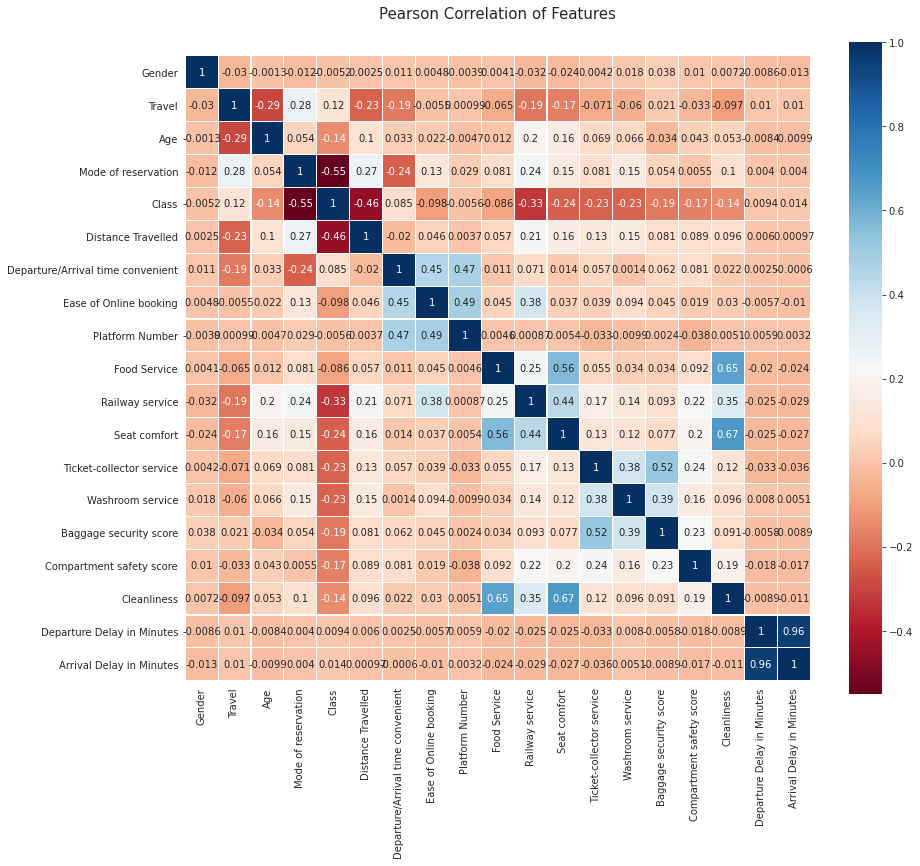

In [105]:
colormap = plt.cm.RdBu
plt.figure(figsize=(14,12))
plt.title('Pearson Correlation of Features', y=1.05, size=15)
sns.heatmap(X.astype(float).corr(),linewidths=0.1,vmax=1.0, 
            square=True, cmap=colormap, linecolor='white', annot=True)

In [106]:
ss_lst = Continious_cols

std_sc = StandardScaler()
std_sc.fit(X[ss_lst])

X_temp = X.copy()
test_data_temp = test_data.copy()

X_temp[ss_lst] = std_sc.transform(X[ss_lst])
test_data_temp[ss_lst] = std_sc.transform(test_data[ss_lst])

X = X_temp
test_data = test_data_temp

In [107]:
X

,Gender,Travel,Age,Mode of reservation,Class,Distance Travelled,Departure/Arrival time convenient,Ease of Online booking,Platform Number,Food Service,Railway service,Seat comfort,Ticket-collector service,Washroom service,Baggage security score,Compartment safety score,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
1,0,0,-0.105105,1,2,-1.017292,4,4,4,4,4,4,2,5,4,2,4,1.023001,1.601146
3,1,1,-0.577428,1,2,-0.352376,3,3,5,4,3,4,4,2,2,1,4,0.463374,0.343109
5,1,0,-1.657023,0,0,0.926310,4,3,4,1,3,4,4,3,4,4,1,-0.389391,-0.364537
7,1,0,1.784188,0,2,-0.578605,4,3,1,4,3,4,5,2,4,4,4,1.182895,1.155592
8,1,0,-0.105105,1,2,-0.952374,2,2,2,4,4,4,4,2,4,3,4,-0.389391,0.107227
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18536,0,0,-0.914801,1,0,2.618109,2,2,2,3,4,3,4,5,5,5,3,-0.016306,-0.207282
23495,0,0,0.299744,1,0,-0.934670,5,4,4,2,4,5,5,5,5,3,3,-0.256146,-0.312118
7185,0,0,-0.240054,1,0,-1.029096,4,0,1,2,5,5,3,3,3,5,5,-0.389391,-0.390746
14561,1,0,-0.914801,1,0,-0.306146,2,1,2,5,5,5,3,4,5,3,5,-0.389391,-0.233491


In [108]:
del X["Cleanliness"]
del test_data["Cleanliness"]

del X['Departure Delay in Minutes']
del test_data['Departure Delay in Minutes']

In [109]:
Categorical_cols = ['Gender', 'Travel', 'Mode of reservation', 'Class',
       'Departure/Arrival time convenient',
       'Ease of Online booking', 'Platform Number', 'Food Service',
       'Railway service', 'Seat comfort', 'Ticket-collector service',
       'Washroom service', 'Baggage security score',
       'Compartment safety score']

Continious_cols = ['Age','Distance Travelled', 'Arrival Delay in Minutes']

Non_numerical_cols = ['Gender','Travel','Mode of reservation','Class']

Target_col = ['satisfaction']

In [110]:

def one_hot_enc(X):
#     X = pd.concat([X,pd.get_dummies(X["Gender"],prefix='Gender')],axis=1)
    for a in Categorical_cols:
        X = pd.concat([X,pd.get_dummies(X[a],prefix=a)],axis=1)
    
    X.drop(Categorical_cols,axis=1, inplace=True)
    return X

X_OHE = one_hot_enc(X)
test_data_OHE = one_hot_enc(test_data)
y_OHE = pd.get_dummies(y)

X_OHE

,Age,Distance Travelled,Arrival Delay in Minutes,Gender_0,Gender_1,Travel_0,Travel_1,Mode of reservation_0,Mode of reservation_1,Class_0,Class_1,Class_2,Departure/Arrival time convenient_0,Departure/Arrival time convenient_1,Departure/Arrival time convenient_2,Departure/Arrival time convenient_3,Departure/Arrival time convenient_4,Departure/Arrival time convenient_5,Ease of Online booking_0,Ease of Online booking_1,Ease of Online booking_2,Ease of Online booking_3,Ease of Online booking_4,Ease of Online booking_5,Platform Number_1,Platform Number_2,Platform Number_3,Platform Number_4,Platform Number_5,Food Service_1,Food Service_2,Food Service_3,Food Service_4,Food Service_5,Railway service_1,Railway service_2,Railway service_3,Railway service_4,Railway service_5,Seat comfort_1,Seat comfort_2,Seat comfort_3,Seat comfort_4,Seat comfort_5,Ticket-collector service_1,Ticket-collector service_2,Ticket-collector service_3,Ticket-collector service_4,Ticket-collector service_5,Washroom service_1,Washroom service_2,Washroom service_3,Washroom service_4,Washroom service_5,Baggage security score_1,Baggage security score_2,Baggage security score_3,Baggage security score_4,Baggage security score_5,Compartment safety score_1,Compartment safety score_2,Compartment safety score_3,Compartment safety score_4,Compartment safety score_5
1,-0.105105,-1.017292,1.601146,1,0,1,0,0,1,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,1,0,0,0
3,-0.577428,-0.352376,0.343109,0,1,0,1,0,1,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0
5,-1.657023,0.926310,-0.364537,0,1,1,0,1,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0
7,1.784188,-0.578605,1.155592,0,1,1,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0
8,-0.105105,-0.952374,0.107227,0,1,1,0,0,1,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18536,-0.914801,2.618109,-0.207282,1,0,1,0,0,1,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1
23495,0.299744,-0.934670,-0.312118,1,0,1,0,0,1,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0
7185,-0.240054,-1.029096,-0.390746,1,0,1,0,0,1,1,0,0,0,0,0,0,1,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1
14561,-0.914801,-0.306146,-0.233491,0,1,1,0,0,1,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,1,0,0


In [111]:
# from sklearn.preprocessing import RobustScaler
# cols = X_OHE.columns

# scaler = RobustScaler()

# X_OHE = scaler.fit_transform(X_OHE)
# test_data_OHE = scaler.transform(test_data_OHE)

# X_OHE = pd.DataFrame(X_OHE, columns=[cols])
# test_data_OHE = pd.DataFrame(test_data_OHE, columns=[cols])
# X_OHE

In [112]:
X_OHE = X_OHE.values
y_OHE = y_OHE.values
test_data_OHE = test_data_OHE.values
y=y.values

In [113]:
X_train_OHE, X_test_OHE, y_train, y_test = train_test_split(X_OHE, y, test_size=5, random_state=42, shuffle=True, stratify=y)


In [114]:
from sklearn.metrics import roc_auc_score

def get_accuracy(y_pred, y):
    return roc_auc_score(y_pred, y)

# MODEL tester

In [115]:
from sklearn.metrics import accuracy_score
from catboost import CatBoostClassifier

def run_model(MODEL):
    MODEL.fit(X_train_OHE, y_train)

    pred_train = MODEL.predict(X_train_OHE)
    print( "Train acc = ",get_accuracy(y_train, pred_train) )

    pred_val = MODEL.predict(X_test_OHE)
    print( "Validation acc = ",get_accuracy(y_test, pred_val) )

    pred_test = MODEL.predict(test_data_OHE)
    ss["satisfaction"] = pred_test
    print(ss["satisfaction"].value_counts())
    print(ss.head())
    ss.to_csv('level_01_data/{}_Submission.csv'.format(MODEL), index=False) 

    return MODEL 

%time
KNC = KNeighborsClassifier(n_neighbors=15)
GNB = GaussianNB()
RFC = RandomForestClassifier(n_estimators=300, criterion='entropy', max_depth=None, oob_score=True )
# SVC_lin = SVC(kernel="linear", random_state=101)
CBC = CatBoostClassifier(iterations=10000MODE, learning_rate=0.1) #loss_function='CrossEntropy')
#9999:	learn: 0.0699153

RFC = run_model(CBC)
%time
#0.91666 - VA test size = 12, any scaling



CPU times: user 4 µs, sys: 0 ns, total: 4 µs
Wall time: 10.5 µs
0:	learn: 0.5713269	total: 117ms	remaining: 19m 29s
1:	learn: 0.5038891	total: 164ms	remaining: 13m 38s
2:	learn: 0.4599430	total: 212ms	remaining: 11m 46s
3:	learn: 0.4275540	total: 262ms	remaining: 10m 54s
4:	learn: 0.3998369	total: 306ms	remaining: 10m 12s
5:	learn: 0.3741947	total: 367ms	remaining: 10m 11s
6:	learn: 0.3458871	total: 419ms	remaining: 9m 58s
7:	learn: 0.3320577	total: 466ms	remaining: 9m 42s
8:	learn: 0.3203740	total: 509ms	remaining: 9m 25s
9:	learn: 0.3012560	total: 560ms	remaining: 9m 19s
10:	learn: 0.2912431	total: 650ms	remaining: 9m 50s
11:	learn: 0.2830191	total: 695ms	remaining: 9m 38s
12:	learn: 0.2767993	total: 738ms	remaining: 9m 26s
13:	learn: 0.2702137	total: 766ms	remaining: 9m 6s
14:	learn: 0.2592646	total: 795ms	remaining: 8m 48s
15:	learn: 0.2548524	total: 824ms	remaining: 8m 34s
16:	learn: 0.2510562	total: 860ms	remaining: 8m 24s
17:	learn: 0.2439754	total: 896ms	remaining: 8m 17s
18:	l

In [37]:
# grid_n_estimator = [10, 50, 100, 300, 500]
# grid_max_depth = [2, 4, 6, 8, 10, None]
# grid_criterion = ['gini', 'entropy']
# grid_bool = [True, False]
# grid_seed = [0]

# param=[{
# #RandomForestClassifier - http://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html#sklearn.ensemble.RandomForestClassifier
# 'n_estimators': grid_n_estimator, #default=10
# 'criterion': grid_criterion, #default=”gini”
# 'max_depth': grid_max_depth, #default=None
# 'oob_score': [True], #default=False -- 12/31/17 set to reduce runtime -- The best parameter for RandomForestClassifier is {'criterion': 'entropy', 'max_depth': 6, 'n_estimators': 100, 'oob_score': True, 'random_state': 0} with a runtime of 146.35 seconds.
# 'random_state': grid_seed
# }]

In [38]:
# import time
# start = time.perf_counter()
# RFC_ = RandomForestClassifier()
# best_search = model_selection.GridSearchCV(estimator = RFC_, param_grid = param, scoring = 'accuracy')
# best_search.fit(X_train_OHE, y_train)
# run = time.perf_counter() - start

# best_param = best_search.best_params_
# print('The best parameter for {} is {} with a runtime of {:.2f} seconds.'.format(RFC_.__class__.__name__, best_param, run))
# RFC_.set_params(**best_param) 

In [39]:
# print(best_param)

In [40]:
from sklearn.ensemble import RandomForestClassifier, VotingClassifier

eclf1 = VotingClassifier(estimators=[('rfc1', RFC_1), ('rfc2', RFC_2), ('rfc', RFC)], voting='hard')
eclf1 = eclf1.fit(X_train_OHE, y_train)

pred_train = eclf1.predict(X_train_OHE)
print( "Train acc = ",get_accuracy(y_train, pred_train) )

pred_val = eclf1.predict(X_test_OHE)
print( "Validation acc = ",get_accuracy(y_test, pred_val) )

pred_test = eclf1.predict(test_data_OHE)
ss["Occupation"] = pred_test
print(ss["Occupation"].value_counts())
print(ss.head())
ss.to_csv('ENSEMBLE_RFC_2xSVM_hard.csv', index=False)  

Train acc =  1.0
Validation acc =  1.0
7     4454
0     3907
3     1553
4     1354
10     956
6      850
5      282
9      142
2       59
1       55
8       24
11      23
Name: Occupation, dtype: int64
   Id  Occupation
0   5           0
1   6           0
2  11           7
3  12           7
4  13          10
